In [43]:
import numpy as np
import pandas as pd
from math import exp
from matplotlib import pyplot, animation
import matplotlib.pyplot as plt
from numpy import sqrt

In [44]:
def u_0(x):
    if x <= 1 and x >=-1:
        return 5
    else :
        return 0

In [45]:
def F(u):
    return c*u

In [46]:
def U_ex(x, t):
    return u_0(x-c*t)

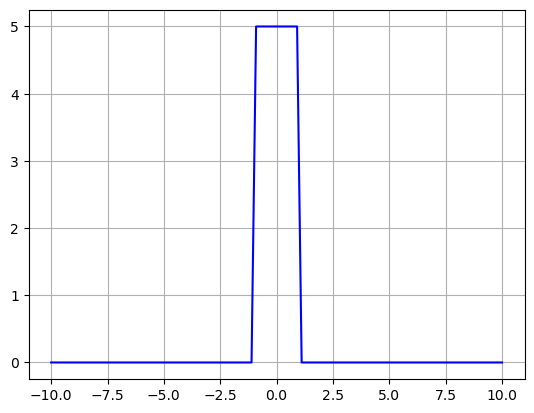

In [47]:
a = -10
b = 10
c = 2
N = 100
dx = (b-a)/(N-1)
x = np.linspace(a,b,N)
Un = np.zeros(N)
for i in range(N):
    Un[i] = u_0(x[i])
plt.plot(x,Un,'-b')
plt.grid()

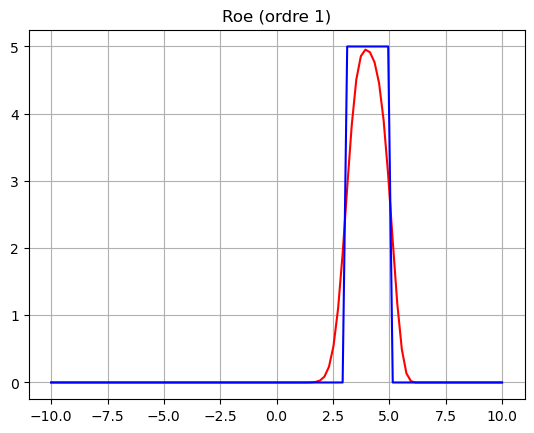

In [48]:
cfl = 0.8
dt = (cfl*dx)/abs(c)
temps = 0
T_final = 2
Unp1 = np.zeros(N)
lam = dt/dx
while(temps < T_final):
    for i in range(1,N-1):
        Fg = (0.5)*(F(Un[i-1]) + F(Un[i])) - 0.5*abs(c)*(Un[i]-Un[i-1])
        Fd = (0.5)*(F(Un[i]) + F(Un[i+1])) - 0.5*abs(c)*(Un[i+1]-Un[i])
        Unp1[i] = Un[i] - lam*(Fd-Fg)
    Unp1[0]= Unp1[1]
    Unp1[N-1]= Unp1[N-2]
    temps = temps + dt
    Un = Unp1.copy()
    Uex = [U_ex(i,temps) for i in x]
plt.plot(x,Un,'-r')
plt.plot(x,Uex,'-b') 
plt.title('Roe (ordre 1)')
plt.grid()
    
